# US Census Demographic Data
### Predykcja dochodu na osobę w zależności od danych demograficznych i ekonomicznych w Stanach Zjednoczonych

In [21]:
import numpy as np
import pandas as pd

Wczytanie zbioru i określenie liczby hrabstw

In [22]:
df = pd.read_csv("data/acs2017_county_data.csv")

display(df.head())

num_counties = df.shape[0]
print("Liczba hrabstw:",num_counties)

num_attr = df.shape[1]
print("Liczba atrybutów:", num_attr)

print("Nazwy atrybutów:")
print(df.columns.values)

df.drop_duplicates()

num_counties_aft_drop = df.shape[0]
if num_counties != num_counties_aft_drop:
    print("Występują powtórzenia w zbiorze i jest ich:", num_counties - num_counties_aft_drop)

,CountyId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,1001,Alabama,Autauga County,55036,26899,28137,2.7,75.4,18.9,0.3,...,0.6,1.3,2.5,25.8,24112,74.1,20.2,5.6,0.1,5.2
1,1003,Alabama,Baldwin County,203360,99527,103833,4.4,83.1,9.5,0.8,...,0.8,1.1,5.6,27.0,89527,80.7,12.9,6.3,0.1,5.5
2,1005,Alabama,Barbour County,26201,13976,12225,4.2,45.7,47.8,0.2,...,2.2,1.7,1.3,23.4,8878,74.1,19.1,6.5,0.3,12.4
3,1007,Alabama,Bibb County,22580,12251,10329,2.4,74.6,22.0,0.4,...,0.3,1.7,1.5,30.0,8171,76.0,17.4,6.3,0.3,8.2
4,1009,Alabama,Blount County,57667,28490,29177,9.0,87.4,1.5,0.3,...,0.4,0.4,2.1,35.0,21380,83.9,11.9,4.0,0.1,4.9


Liczba hrabstw: 3220
Liczba atrybutów: 37
Nazwy atrybutów:
['CountyId' 'State' 'County' 'TotalPop' 'Men' 'Women' 'Hispanic' 'White'
 'Black' 'Native' 'Asian' 'Pacific' 'VotingAgeCitizen' 'Income'
 'IncomeErr' 'IncomePerCap' 'IncomePerCapErr' 'Poverty' 'ChildPoverty'
 'Professional' 'Service' 'Office' 'Construction' 'Production' 'Drive'
 'Carpool' 'Transit' 'Walk' 'OtherTransp' 'WorkAtHome' 'MeanCommute'
 'Employed' 'PrivateWork' 'PublicWork' 'SelfEmployed' 'FamilyWork'
 'Unemployment']


Analiza braków danych

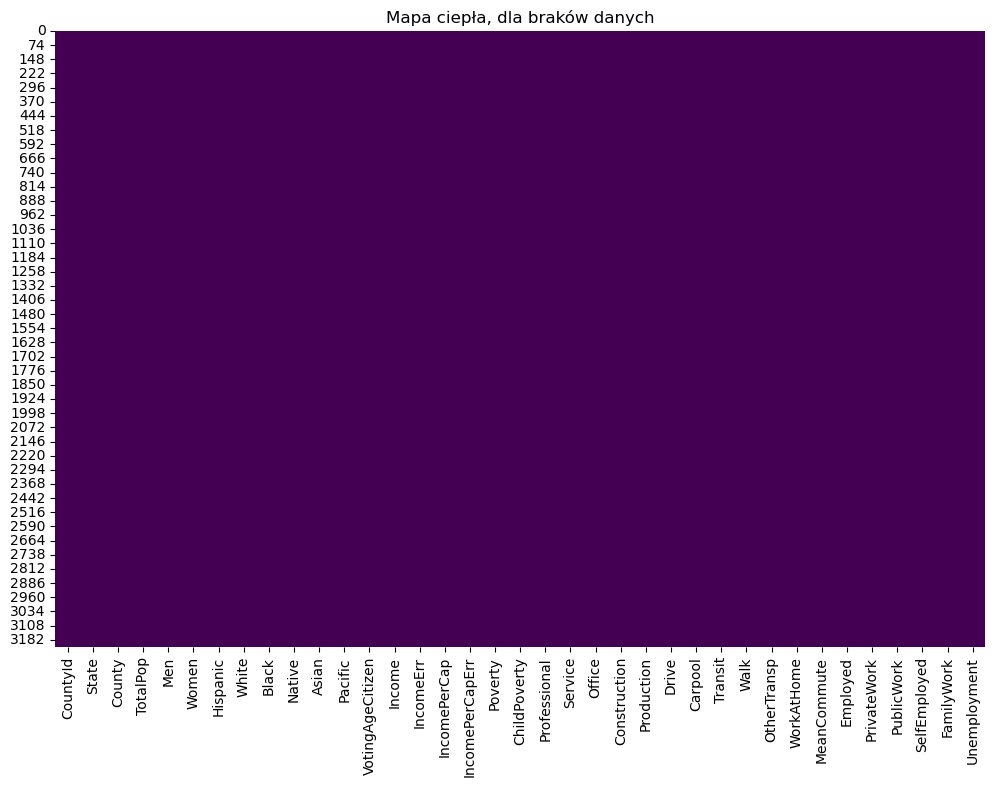


Braki w danych liczone wg. atrybutów
ChildPoverty    1
dtype: int64

Braki w danych liczone wg. obiektów

Braki w danych liczone wg. obiektów
548    1
dtype: int64


(ChildPoverty    1
 dtype: int64,
 548    1
 dtype: int64)

In [23]:
from missing_values import analyze

analyze(df)

In [24]:
print("Hrabstwo, dla którego występuje brak:", df.loc[548, "County"])
print("Jego liczba mieszkańców:", df.loc[548, "TotalPop"])

Hrabstwo, dla którego występuje brak: Kalawao County
Jego liczba mieszkańców: 86


Hrabstwo to ma 86 mieszkańców i znajduje się w stanie Hawaii (jest to wyspa), więc myślę, że można je pominąć w analizie

Kolumna, dla której występował brak

In [25]:
df["ChildPoverty"]

0       20.1
1       16.1
2       44.9
3       26.6
4       25.4
        ... 
3215    49.4
3216    68.2
3217    67.9
3218    62.1
3219    58.2
Name: ChildPoverty, Length: 3220, dtype: float64

In [26]:
df = df.dropna()
print("Ilość obiektów po usunięcie braków:", df.shape[0])

Ilość obiektów po usunięcie braków: 3219


In [27]:
# indeksy atrybutów, które chcemy wczytać
col_idx = list(range(213, 225))
col_idx.insert(0, 2)
df_m = pd.read_csv("data/County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv", usecols = col_idx)

df_m.head()

,RegionName,2017-01-31,2017-02-28,2017-03-31,2017-04-30,2017-05-31,2017-06-30,2017-07-31,2017-08-31,2017-09-30,2017-10-31,2017-11-30,2017-12-31
0,Los Angeles County,496432.165871,507859.677641,520913.658719,530631.397967,537244.275959,542477.432796,542385.620441,540013.644416,536369.348970,536864.968049,538689.381948,541662.049466
1,Cook County,213212.551902,214911.562420,216700.376163,217918.756026,218702.731358,218548.139244,218452.791111,218348.257780,219114.410602,220283.185939,221663.939129,223089.429643
2,Harris County,178867.362531,179293.936080,179865.512649,180606.507008,181295.097794,181900.420107,182275.200113,182736.328973,183150.923275,183801.630746,184547.835710,185331.960500
3,Maricopa County,246051.872009,247371.898175,248821.126990,250356.606120,251795.821571,253212.799829,254578.486102,256004.502478,257477.687867,259015.835934,260282.302938,261556.469755
4,San Diego County,527134.172852,531398.707245,534337.134033,537429.740566,540009.645298,543344.843806,545744.662180,549008.592430,552204.949203,556710.483291,560643.580571,565084.374180


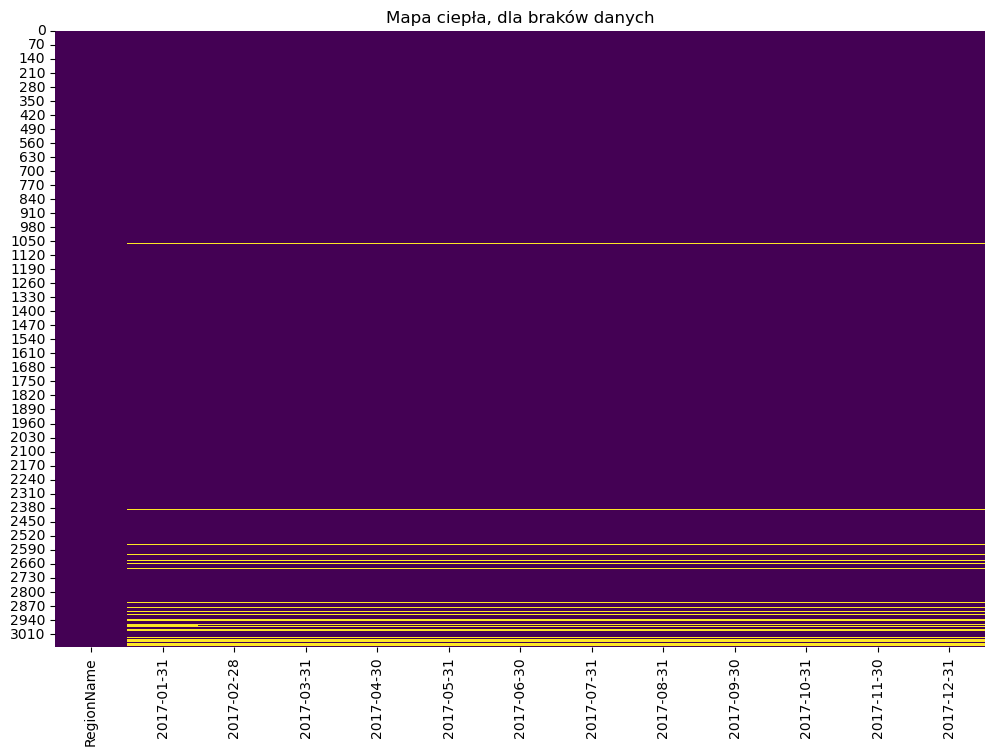


Braki w danych liczone wg. atrybutów
2017-01-31    101
2017-02-28     95
2017-03-31     94
2017-04-30     94
2017-05-31     94
2017-06-30     94
2017-07-31     94
2017-08-31     94
2017-09-30     94
2017-10-31     94
2017-11-30     94
2017-12-31     94
dtype: int64

Braki w danych liczone wg. obiektów

Braki w danych liczone wg. obiektów
1062    12
1734    12
1857    12
2062    12
2161     1
        ..
3068    12
3069    12
3070    12
3071    12
3072    12
Length: 101, dtype: int64


In [28]:
from missing_values import analyze

missing_attributes, missing_objects = analyze(df_m)

In [29]:
print(missing_attributes)
print(missing_objects)

2017-01-31    101
2017-02-28     95
2017-03-31     94
2017-04-30     94
2017-05-31     94
2017-06-30     94
2017-07-31     94
2017-08-31     94
2017-09-30     94
2017-10-31     94
2017-11-30     94
2017-12-31     94
dtype: int64
1062    12
1734    12
1857    12
2062    12
2161     1
        ..
3068    12
3069    12
3070    12
3071    12
3072    12
Length: 101, dtype: int64


In [30]:
missing_objects_filtred = missing_objects[missing_objects > 6]
missing_objects_filtred
type(missing_objects.index.values)
df_m.loc[missing_objects_filtred.index.values, :]

,RegionName,2017-01-31,2017-02-28,2017-03-31,2017-04-30,2017-05-31,2017-06-30,2017-07-31,2017-08-31,2017-09-30,2017-10-31,2017-11-30,2017-12-31
1062,Washington County,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1734,Wyoming County,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1857,McDowell County,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2062,Lawrence County,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2172,McKenzie County,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3068,Loup County,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3069,Banner County,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3070,Daggett County,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3071,Thomas County,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Ponieważ hrabstw, dla których nie mamy co najmiej połowy średniej ceny domów w ciągu roku, nie jest tak dużo, dokładnie 94, nie będziemy dalej uwzględniać tych danych, gdyż jest to ok 3% danych z całego zbioru.

In [31]:
df_m_cleaned = df_m.dropna(subset=df_m.columns[1:], how='all')

df_m_cleaned = df_m_cleaned.assign(Average_House_Price=df_m_cleaned.iloc[:, 1:].mean(axis=1))
df_m_cleaned.drop(df_m_cleaned.columns[1:13], axis = 1, inplace = True)
df_m_cleaned = df_m_cleaned.rename(columns={"RegionName": "County",})
df_m_cleaned

,County,Average_House_Price
0,Los Angeles County,530961.968520
1,Cook County,218412.177610
2,Harris County,181972.726290
3,Maricopa County,253877.117481
4,San Diego County,545254.240471
...,...,...
3064,Grant County,69287.857213
3065,Hooker County,52497.702073
3066,San Juan County,257210.006821
3067,Treasure County,101346.544846


Trzeba dodać kolumnę State, bo same nazwy Hrabstw się powtarzają

In [ ]:
# słownik skrótów na pełne nazwy stanów
state_abbrev_to_name = {
    'AL': 'Alabama',
    'AK': 'Alaska',
    'AZ': 'Arizona',
    'AR': 'Arkansas',
    'CA': 'California',
    'CO': 'Colorado',
    'CT': 'Connecticut',
    'DE': 'Delaware',
    'FL': 'Florida',
    'GA': 'Georgia',
    'HI': 'Hawaii',
    'ID': 'Idaho',
    'IL': 'Illinois',
    'IN': 'Indiana',
    'IA': 'Iowa',
    'KS': 'Kansas',
    'KY': 'Kentucky',
    'LA': 'Louisiana',
    'ME': 'Maine',
    'MD': 'Maryland',
    'MA': 'Massachusetts',
    'MI': 'Michigan',
    'MN': 'Minnesota',
    'MS': 'Mississippi',
    'MO': 'Missouri',
    'MT': 'Montana',
    'NE': 'Nebraska',
    'NV': 'Nevada',
    'NH': 'New Hampshire',
    'NJ': 'New Jersey',
    'NM': 'New Mexico',
    'NY': 'New York',
    'NC': 'North Carolina',
    'ND': 'North Dakota',
    'OH': 'Ohio',
    'OK': 'Oklahoma',
    'OR': 'Oregon',
    'PA': 'Pennsylvania',
    'RI': 'Rhode Island',
    'SC': 'South Carolina',
    'SD': 'South Dakota',
    'TN': 'Tennessee',
    'TX': 'Texas',
    'UT': 'Utah',
    'VT': 'Vemont',
    'VA': 'Virginia',
    'WA': 'Washington',
    'WV': 'West Virginia',
    'WI': 'Wisconsin',
    'WY': 'Wyoming'
}

In [32]:
dd=  df.merge(df_m_cleaned, on = "County")
dd

,CountyId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment,Average_House_Price
0,1001,Alabama,Autauga County,55036,26899,28137,2.7,75.4,18.9,0.3,...,1.3,2.5,25.8,24112,74.1,20.2,5.6,0.1,5.2,165762.733670
1,1003,Alabama,Baldwin County,203360,99527,103833,4.4,83.1,9.5,0.8,...,1.1,5.6,27.0,89527,80.7,12.9,6.3,0.1,5.5,220506.516160
2,1003,Alabama,Baldwin County,203360,99527,103833,4.4,83.1,9.5,0.8,...,1.1,5.6,27.0,89527,80.7,12.9,6.3,0.1,5.5,108339.852594
3,13009,Georgia,Baldwin County,45527,22893,22634,2.2,52.9,41.4,0.3,...,1.4,1.7,21.7,17647,68.6,27.7,3.7,0.0,9.0,220506.516160
4,13009,Georgia,Baldwin County,45527,22893,22634,2.2,52.9,41.4,0.3,...,1.4,1.7,21.7,17647,68.6,27.7,3.7,0.0,9.0,108339.852594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13922,56035,Wyoming,Sublette County,10037,5447,4590,7.3,89.2,0.0,0.1,...,0.9,7.0,20.9,5396,72.6,23.9,3.4,0.2,4.2,296457.732397
13923,56037,Wyoming,Sweetwater County,44527,22981,21546,16.0,79.6,0.8,0.6,...,1.3,1.5,20.5,22739,78.4,17.8,3.8,0.0,5.2,215516.381769
13924,56041,Wyoming,Uinta County,20758,10593,10165,9.1,87.7,0.1,0.9,...,1.3,2.0,19.9,9528,71.5,21.5,6.6,0.4,6.4,186634.689280
13925,56043,Wyoming,Washakie County,8253,4118,4135,14.2,82.2,0.3,0.4,...,1.3,4.4,14.3,3833,69.8,22.0,8.1,0.2,6.1,167179.509742


Sprawdzenie wypełnienia dla lat 2015:
 - Usunięte względem poprzedniego commita
 - W zbiorze danych z Zillow po prostu było za dużo braków dla 2015 (ponad 500), gdzie dla 2017 jest ich mniej (około 100)